# UWB LOS/NLOS Classification & Distance Estimation — Exploratory Data Analysis
**Course:** CSC3105 Data Analytics and AI  
**Dataset:** UWB-LOS-NLOS-Dataset (Decawave DWM1000, 42,000 samples, 7 indoor environments)  

---

## Overview
This juypter notebook is a breakdown of the exploratory data analysis the team has done to understand the dataset provided and find for important features for modelling usage. At the end of this exploratory, a new dataset file will be created which would be used as the import file for the Machine Learning models.

## 1. Imports

In [6]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)

In [7]:
# Paths
BASE_DIR = Path(".")
DATASET_DIR = BASE_DIR / "Dataset" / "UWB-LOS-NLOS-Data-Set" / "dataset"

# Print this to find location of dataset
# print(f"\nDataset: {DATASET_DIR.absolute()}")

## 2. Load and Merge Database
This section loads the individual dataset parts and merges them into a single DataFrame. The merging process ensures that all samples from the provided dataset segments are combined into one unified dataset for analysis. An additional column named `dataset_part` is created for our own knowledge to know where each instance of data is coming from.

In [8]:
all_files = list(DATASET_DIR.glob("*.csv"))
print(f"Found {len(all_files)} CSV files")

dataframes = []
for i, file in enumerate(all_files):
    print(f"  Loading {i+1}/{len(all_files)}: {file.name}...", end='\r')
    df_temp = pd.read_csv(file)
    df_temp['dataset_part'] = file.stem
    dataframes.append(df_temp)

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"\nLoaded {len(df_raw):,} total rows from {len(all_files)} files.")

Found 7 CSV files



Loaded 42,000 total rows from 7 files.


## 3. Database Structured Check
This section examines the overall structure of the dataset by inspecting the column names, data types, and basic statistical summaries. The dataset was also separated into **metadata features** and **CIR waveform samples** to facilitate more meaningful exploration.

### Findings
- The dataset contains both LOS (Line-of-Sight) and NLOS (Non-Line-of-Sight) signal measurements.
- The final dataset contains **1032 columns**, consisting of metadata features and CIR signal samples.
- The dataset contains:
  - 1 dataset origin
  - 1 target column (NLOS)
  - 14 metadata features
  - 1016 CIR signal features
- Metadata features describe signal characteristics such as **first path amplitude**, **noise statistics**, and **signal power**.
- CIR columns represent the **Channel Impulse Response waveform**, capturing signal behavior over time.

In [9]:
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"First path columns: {df_raw.columns[:5].tolist()} ...")
print(f"Last CIR columns:   {df_raw.columns[-5:].tolist()}")
print(f"\nData types:\n{df_raw.dtypes.value_counts().to_string()}")

df_raw.head()

Shape: 42,000 rows × 1032 columns
First path columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2'] ...
Last CIR columns:   ['CIR1012', 'CIR1013', 'CIR1014', 'CIR1015', 'dataset_part']

Data types:
float64    1031
str           1


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,CH,FRAME_LEN,PREAM_LEN,BITRATE,PRFR,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,CIR9,CIR10,CIR11,CIR12,CIR13,CIR14,CIR15,CIR16,CIR17,CIR18,CIR19,CIR20,CIR21,CIR22,CIR23,CIR24,CIR25,CIR26,CIR27,CIR28,CIR29,CIR30,CIR31,CIR32,CIR33,CIR34,CIR35,CIR36,CIR37,CIR38,CIR39,CIR40,CIR41,CIR42,CIR43,CIR44,...,CIR957,CIR958,CIR959,CIR960,CIR961,CIR962,CIR963,CIR964,CIR965,CIR966,CIR967,CIR968,CIR969,CIR970,CIR971,CIR972,CIR973,CIR974,CIR975,CIR976,CIR977,CIR978,CIR979,CIR980,CIR981,CIR982,CIR983,CIR984,CIR985,CIR986,CIR987,CIR988,CIR989,CIR990,CIR991,CIR992,CIR993,CIR994,CIR995,CIR996,CIR997,CIR998,CIR999,CIR1000,CIR1001,CIR1002,CIR1003,CIR1004,CIR1005,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015,dataset_part
0,0.0,0.98,746.0,12111.0,18454.0,12836.0,36.0,7402.0,970.0,273.0,2.0,39.0,1024.0,110.0,64.0,341.0,340.0,150.0,50.0,233.0,227.0,160.0,102.0,224.0,252.0,108.0,94.0,91.0,103.0,113.0,121.0,190.0,142.0,53.0,216.0,216.0,107.0,157.0,121.0,84.0,135.0,86.0,58.0,122.0,162.0,241.0,295.0,96.0,229.0,172.0,231.0,217.0,157.0,182.0,267.0,281.0,207.0,71.0,195.0,158.0,...,99.0,203.0,298.0,229.0,254.0,148.0,288.0,104.0,148.0,101.0,104.0,124.0,59.0,103.0,287.0,68.0,304.0,276.0,87.0,72.0,85.0,251.0,227.0,104.0,121.0,78.0,12.0,253.0,317.0,331.0,192.0,50.0,89.0,103.0,251.0,73.0,167.0,137.0,272.0,42.0,93.0,59.0,241.0,39.0,234.0,269.0,210.0,51.0,219.0,90.0,317.0,284.0,204.0,242.0,256.0,249.0,123.0,115.0,0.0,uwb_dataset_part5
1,1.0,7.42,749.0,5416.0,12273.0,11997.0,60.0,12689.0,947.0,463.0,2.0,39.0,1024.0,110.0,64.0,152.0,262.0,262.0,320.0,208.0,411.0,260.0,192.0,185.0,132.0,225.0,305.0,224.0,271.0,233.0,262.0,224.0,218.0,195.0,251.0,90.0,234.0,91.0,381.0,246.0,34.0,239.0,141.0,225.0,222.0,294.0,61.0,246.0,229.0,108.0,263.0,210.0,60.0,355.0,216.0,168.0,232.0,229.0,295.0,344.0,...,464.0,253.0,253.0,310.0,214.0,227.0,308.0,204.0,229.0,252.0,180.0,283.0,303.0,93.0,157.0,114.0,275.0,195.0,491.0,126.0,297.0,324.0,381.0,151.0,172.0,281.0,330.0,147.0,162.0,251.0,311.0,219.0,57.0,253.0,185.0,144.0,130.0,208.0,177.0,93.0,437.0,138.0,464.0,193.0,215.0,304.0,245.0,115.0,136.0,222.0,195.0,255.0,110.0,282.0,128.0,223.0,77.0,303.0,0.0,uwb_dataset_part5
2,0.0,2.09,751.0,14210.0,16912.0,13366.0,88.0,14307.0,1913.0,308.0,2.0,39.0,1024.0,110.0,64.0,473.0,180.0,235.0,120.0,258.0,104.0,175.0,230.0,267.0,218.0,171.0,167.0,187.0,302.0,251.0,406.0,270.0,276.0,386.0,77.0,398.0,174.0,278.0,333.0,216.0,65.0,177.0,277.0,213.0,237.0,476.0,303.0,237.0,319.0,363.0,280.0,369.0,316.0,237.0,252.0,104.0,78.0,264.0,164.0,357.0,...,194.0,267.0,401.0,560.0,312.0,106.0,337.0,262.0,274.0,253.0,140.0,200.0,176.0,32.0,243.0,121.0,143.0,309.0,272.0,303.0,183.0,266.0,63.0,77.0,212.0,148.0,185.0,503.0,167.0,328.0,94.0,148.0,261.0,318.0,309.0,271.0,229.0,79.0,52.0,168.0,117.0,198.0,315.0,352.0,376.0,497.0,159.0,195.0,166.0,52.0,219.0,421.0,202.0,227.0,29.0,268.0,197.0,486.0,0.0,uwb_dataset_part5
3,1.0,6.16,740.0,4905.0,3207.0,5741.0,80.0,2013.0,1194.0,1024.0,2.0,39.0,1024.0,110.0,64.0,211.0,134.0,62.0,204.0,131.0,243.0,230.0,205.0,211.0,229.0,107.0,83.0,178.0,274.0,434.0,385.0,495.0,248.0,310.0,28.0,464.0,337.0,389.0,455.0,483.0,271.0,68.0,406.0,400.0,335.0,172.0,237.0,167.0,569.0,268.0,354.0,297.0,335.0,193.0,292.0,334.0,628.0,298.0,398.0,299.0,...,105.0,213.0,442.0,378.0,128.0,91.0,241.0,253.0,112.0,172.0,141.0,69.0,251.0,155.0,375.0,303.0,60.0,393.0,287.0,262.0,250.0,398.0,409.0,348.0,257.0,107.0,104.0,345.0,249.0,169.0,456.0,306.0,367.0,162.0,232.0,305.0,507.0,140.0,242.0,125.0,523.0,232.0,262.0,92.0,75.0,174.0,388.0,394.0,478.0,39.0,162.0,170.0,241.0,60.0,83.0,309.0,235.0,115.0,0.0,uwb_dataset_part5
4,1.0,6.59,742.0,3445.0,5451.0,4291.0,68.0,3759.0,1018.0,1025.0,2.0,27.0,1536.0,110.0,64.0,396.0,342.0,69.0,317.0,236.0,194.0,192.0,325.0,241.0,229.0,374.0,298.0,472.0,72.0,403.0,472.0,454.0,227.0,95.0,191.0,359.0,180.0,135.0,196.0,436.0,355.0,406.0,344.0,330.0,128.0,567.0,787.0,263.0,242.0

In [10]:
target_col = "NLOS"

# Separate metadata columns and CIR columns for easier and manageable data exploration
# signal statistics
metadata_cols = [
    "RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC",
    "CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"
]

# Only raw Channel Impulse Response (CIR) waveform columns: CIR0 ... CIR1015
cir_cols = sorted(
    [col for col in df_raw.columns if col.startswith("CIR") and col[3:].isdigit()],
    key=lambda x: int(x[3:])
)

print(f"Number of metadata columns: {len(metadata_cols)}")
print(f"Number of CIR columns: {len(cir_cols)}")
print(f"Total columns including label and dataset_part: {len(df_raw.columns)}")

Number of metadata columns: 14
Number of CIR columns: 1016
Total columns including label and dataset_part: 1032


## 4. Data Quality Check
A data quality assessment was conducted to verify the completeness and integrity of the dataset. This involved checking for missing values and duplicate records across all columns.

### Findings
- The dataset contains no missing values.
- No duplicate rows were detected.
- Several metadata features **(CH, BITRATE, PRFR)** were found to have **constant values** across all samples, indicating that these parameters represent fixed hardware configurations during data collection.

The dataset is therefore considered complete and clean, requiring no data cleaning prior to analysis.

In [6]:
missing_counts = df_raw.isna().sum()
missing_nonzero = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Total missing values in dataset:", missing_counts.sum())
print("Columns with missing values:", len(missing_nonzero))
missing_nonzero.head(20)

Total missing values in dataset: 0
Columns with missing values: 0


Series([], dtype: int64)

In [7]:
duplicate_count = df_raw.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [8]:
summary_table = df_raw.describe(include="all").T
summary_table.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NLOS,42000.0,NaN,NaN,NaN,0.5,0.500006,0.0,0.0,0.5,1.0,1.0
RANGE,42000.0,NaN,NaN,NaN,3.831519,2.355976,0.0,1.81,3.48,5.42,28.02
FP_IDX,42000.0,NaN,NaN,NaN,745.654167,4.505024,707.0,744.0,746.0,748.0,848.0
FP_AMP1,42000.0,NaN,NaN,NaN,8127.521905,5393.330697,7.0,3573.75,7140.0,12273.0,20572.0
FP_AMP2,42000.0,NaN,NaN,NaN,11425.259524,6235.434769,63.0,5322.75,12318.0,17310.0,20624.0
FP_AMP3,42000.0,NaN,NaN,NaN,9738.106048,5352.311549,187.0,4723.0,10262.0,14256.0,20577.0
STDEV_NOISE,42000.0,NaN,NaN,NaN,72.284571,29.318995,28.0,56.0,68.0,80.0,324.0
CIR_PWR,42000.0,NaN,NaN,NaN,9789.690214,4912.556005,0.0,6727.0,9950.5,12443.0,37208.0
MAX_NOISE,42000.0,NaN,NaN,NaN,1316.096524,582.434989,310.0,961.0,1134.0,1488.0,5169.0
RXPACC,42000.0,NaN,NaN,NaN,616.2725,306.78537,128.0,318.0,513.0,1024.0,1056.0


## 5. Target / Class Exploration
This section explores the distribution of the target variable to understand the balance between LOS and NLOS samples.

### Findings
- The dataset is balanced between LOS and NLOS samples.
- A balanced dataset helps prevent bias during model training and evaluation.

In [9]:
class_counts = df_raw[target_col].value_counts().sort_index()
class_counts

NLOS
0.0    21000
1.0    21000
Name: count, dtype: int64

In [10]:
# Making clearer labels for analysis
df_raw["class_label"] = df_raw[target_col].map({0: "LOS", 1:"NLOS"})

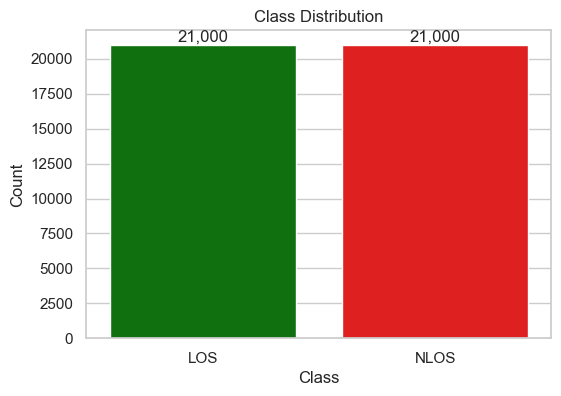

In [11]:
# Class distribution plot
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_raw, x="class_label", hue="class_label", palette=["green", "red"], legend=False)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
               (p.get_x() + p.get_width() / 2, p.get_height()),
               ha="center", va="bottom")

plt.show()

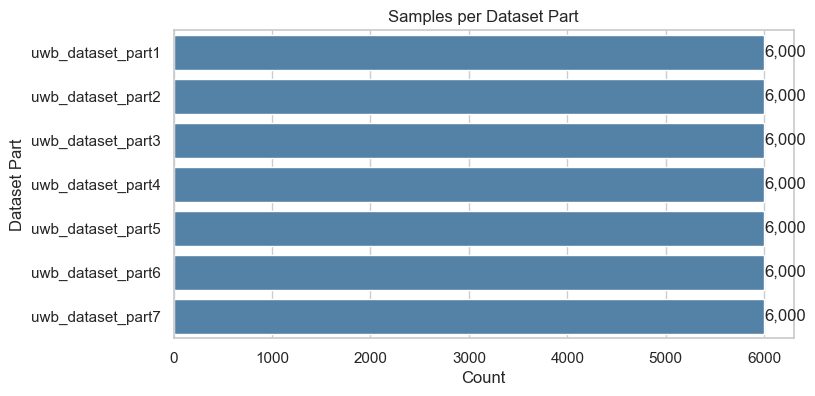

In [12]:
# Samples per source file
plt.figure(figsize=(8,4))
ax = sns.countplot(data=df_raw, y="dataset_part", order=sorted(df_raw["dataset_part"].unique()), color="steelblue")
plt.title("Samples per Dataset Part")
plt.xlabel("Count")
plt.ylabel("Dataset Part")

for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}",
               (p.get_width(), p.get_y() + p.get_height()/ 2),
               ha="left", va="center")

plt.show()

## 6. Metadata feature exploration
The distribution of metadata features was analyzed using histograms and density plots. This helps to understand how individual signal characteristics vary across the dataset.

### Findings
- Signal amplitude features (FP_AMP1, FP_AMP2, FP_AMP3) exhibit noticeable variation across samples.
- Noise-related features (STDEV_NOISE, MAX_NOISE) show wider distributions.
- Certain configuration parameters (CH, BITRATE, PRFR) remain constant, indicating fixed experimental settings.

These observations confirm that metadata features capture important characteristics of the UWB signal.

In [13]:
metadata_summary = df_raw[metadata_cols].describe().T
metadata_summary

,count,mean,std,min,25%,50%,75%,max
RANGE,42000.0,3.831519,2.355976,0.0,1.81,3.48,5.42,28.02
FP_IDX,42000.0,745.654167,4.505024,707.0,744.00,746.00,748.00,848.00
FP_AMP1,42000.0,8127.521905,5393.330697,7.0,3573.75,7140.00,12273.00,20572.00
FP_AMP2,42000.0,11425.259524,6235.434769,63.0,5322.75,12318.00,17310.00,20624.00
FP_AMP3,42000.0,9738.106048,5352.311549,187.0,4723.00,10262.00,14256.00,20577.00
STDEV_NOISE,42000.0,72.284571,29.318995,28.0,56.00,68.00,80.00,324.00
CIR_PWR,42000.0,9789.690214,4912.556005,0.0,6727.00,9950.50,12443.00,37208.00
MAX_NOISE,42000.0,1316.096524,582.434989,310.0,961.00,1134.00,1488.00,5169.00
RXPACC,42000.0,616.272500,306.785370,128.0,318.00,513.00,1024.00,1056.00
CH,42000.0,2.000000,0.000000,2.0,2.00,2.00,2.00,2.00


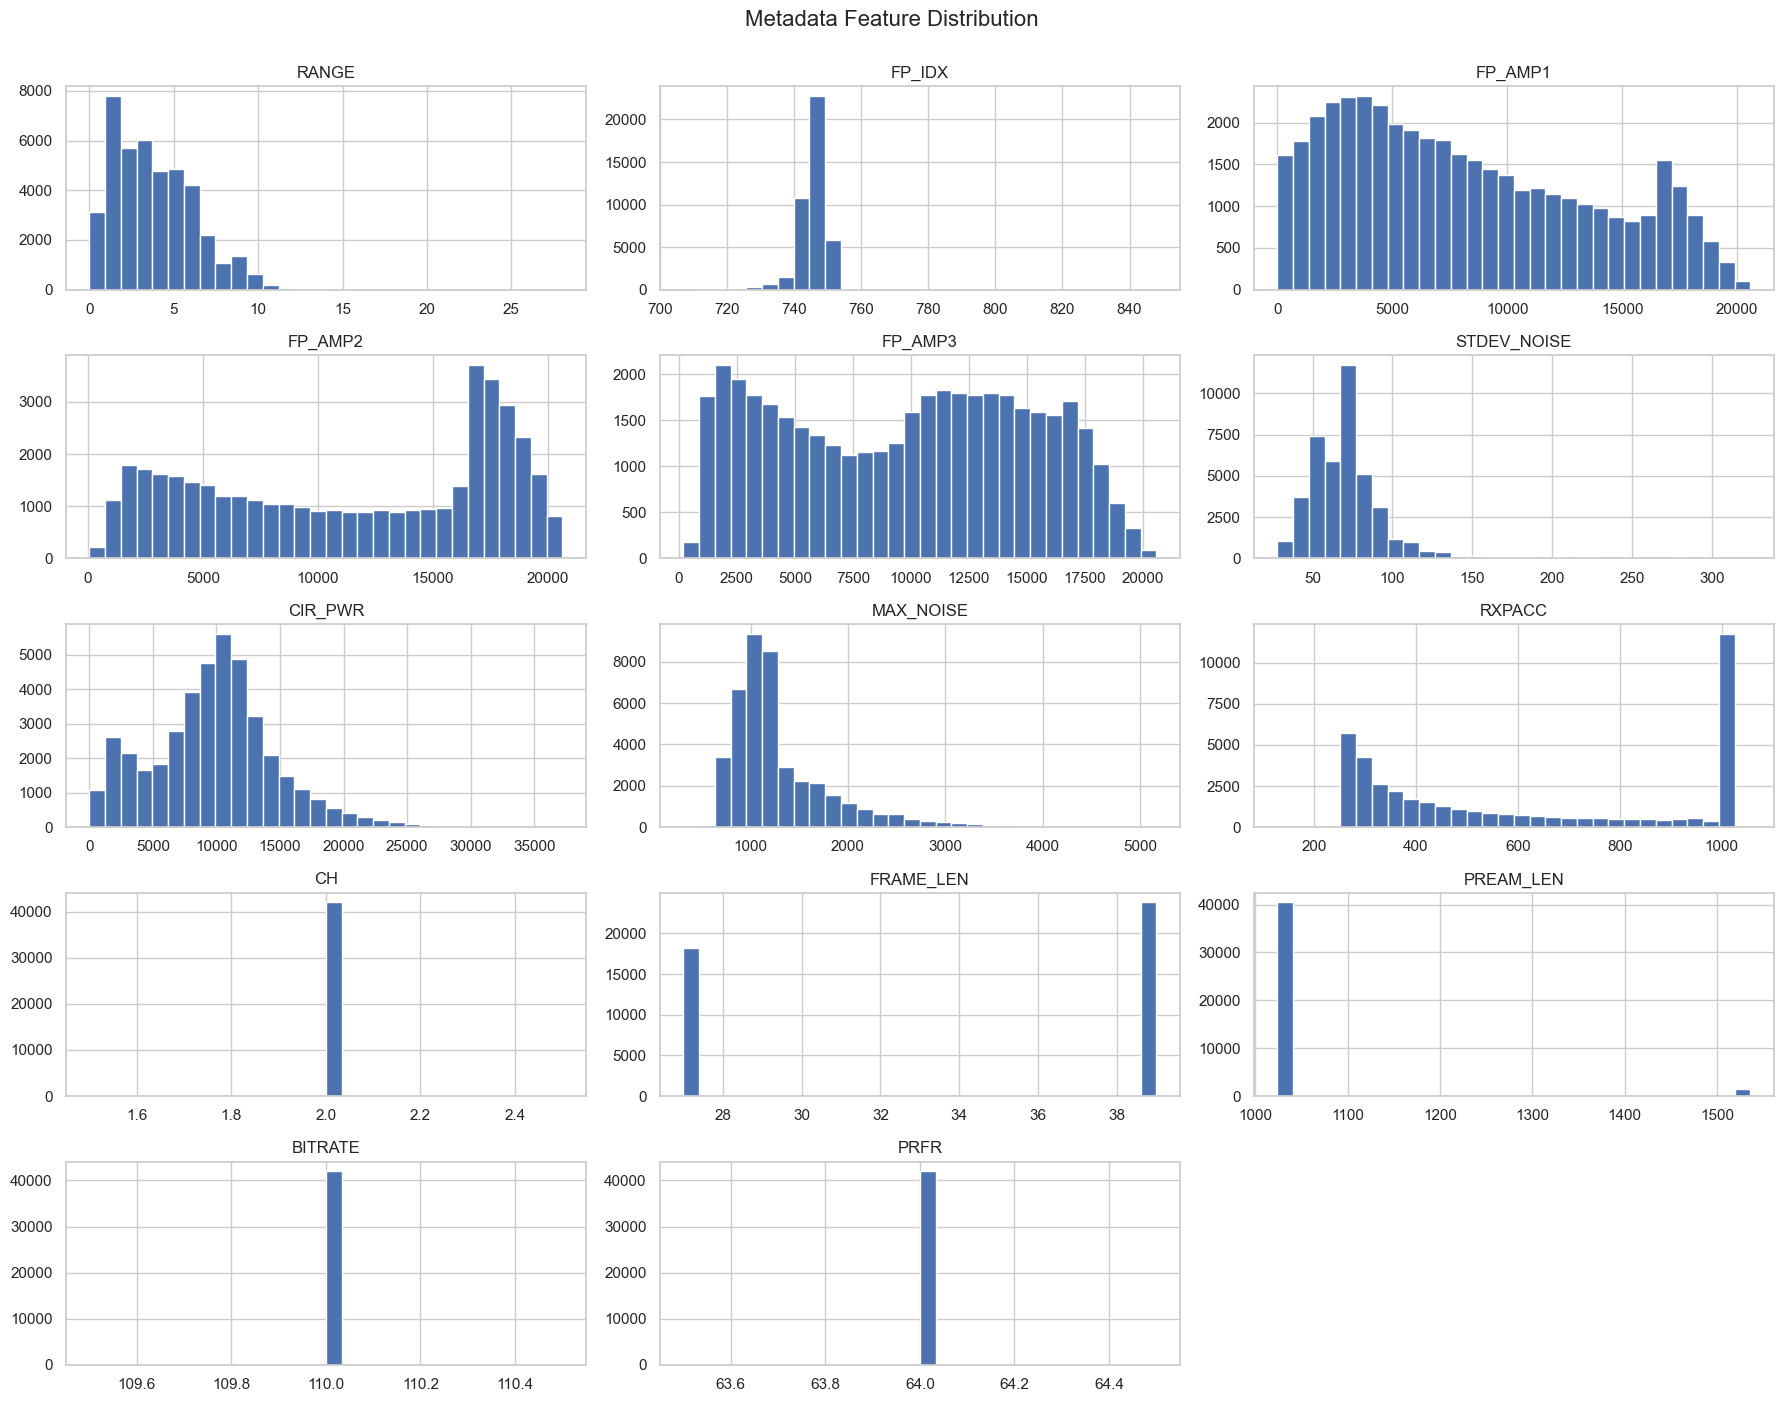

In [14]:
df_raw[metadata_cols].hist(bins=30, figsize=(18, 14), layout=(5, 3))
plt.suptitle("Metadata Feature Distribution", y=1, fontsize = 16)
plt.tight_layout()
plt.show()

## 7. Metadata vs Target Exploration
This section investigates how metadata features differ between LOS and NLOS samples. Kernel density plots were used to visualize the distributions of each feature for both classes.

### Findings
- Noise-related features such as **STDEV_NOISE** and **MAX_NOISE** tend to have higher values for NLOS samples, suggesting that obstructed signals introduce additional noise and signal variation.
- Signal amplitude features (**FP_AMP1–FP_AMP3**) generally appear stronger for LOS samples, reflecting the presence of a direct signal path.
- These differences indicate that metadata features may contain useful information for distinguishing LOS and NLOS conditions.

### Physical & Mathematical Explanation
- **Why is STDEV_NOISE higher for NLOS?** In NLOS, the direct path is blocked, so energy arrives via multiple reflected paths (multipath propagation). Each reflected copy arrives at a slightly different time, and the receiver accumulates these overlapping signals. Their constructive and destructive interference raises the noise floor — mathematically, the received signal $r(t) = \sum_i \alpha_i s(t - \tau_i) + n(t)$ has higher variance when there are many components $i$ with different delays $\tau_i$.

- **Why are FP_AMP values lower for NLOS?** The first-path amplitudes (FP_AMP1–3) measure the signal strength of the direct path at three points around the first detected peak. In NLOS, the direct path must travel through or diffract around an obstacle, losing energy proportional to the material's absorption and scattering coefficients. The received power follows an inverse square law plus an attenuation term: $P_r \propto P_t \cdot \frac{G}{d^2} \cdot e^{-\mu d}$, where $\mu$ is the material's attenuation factor. This explains why NLOS first-path amplitudes are systematically weaker.

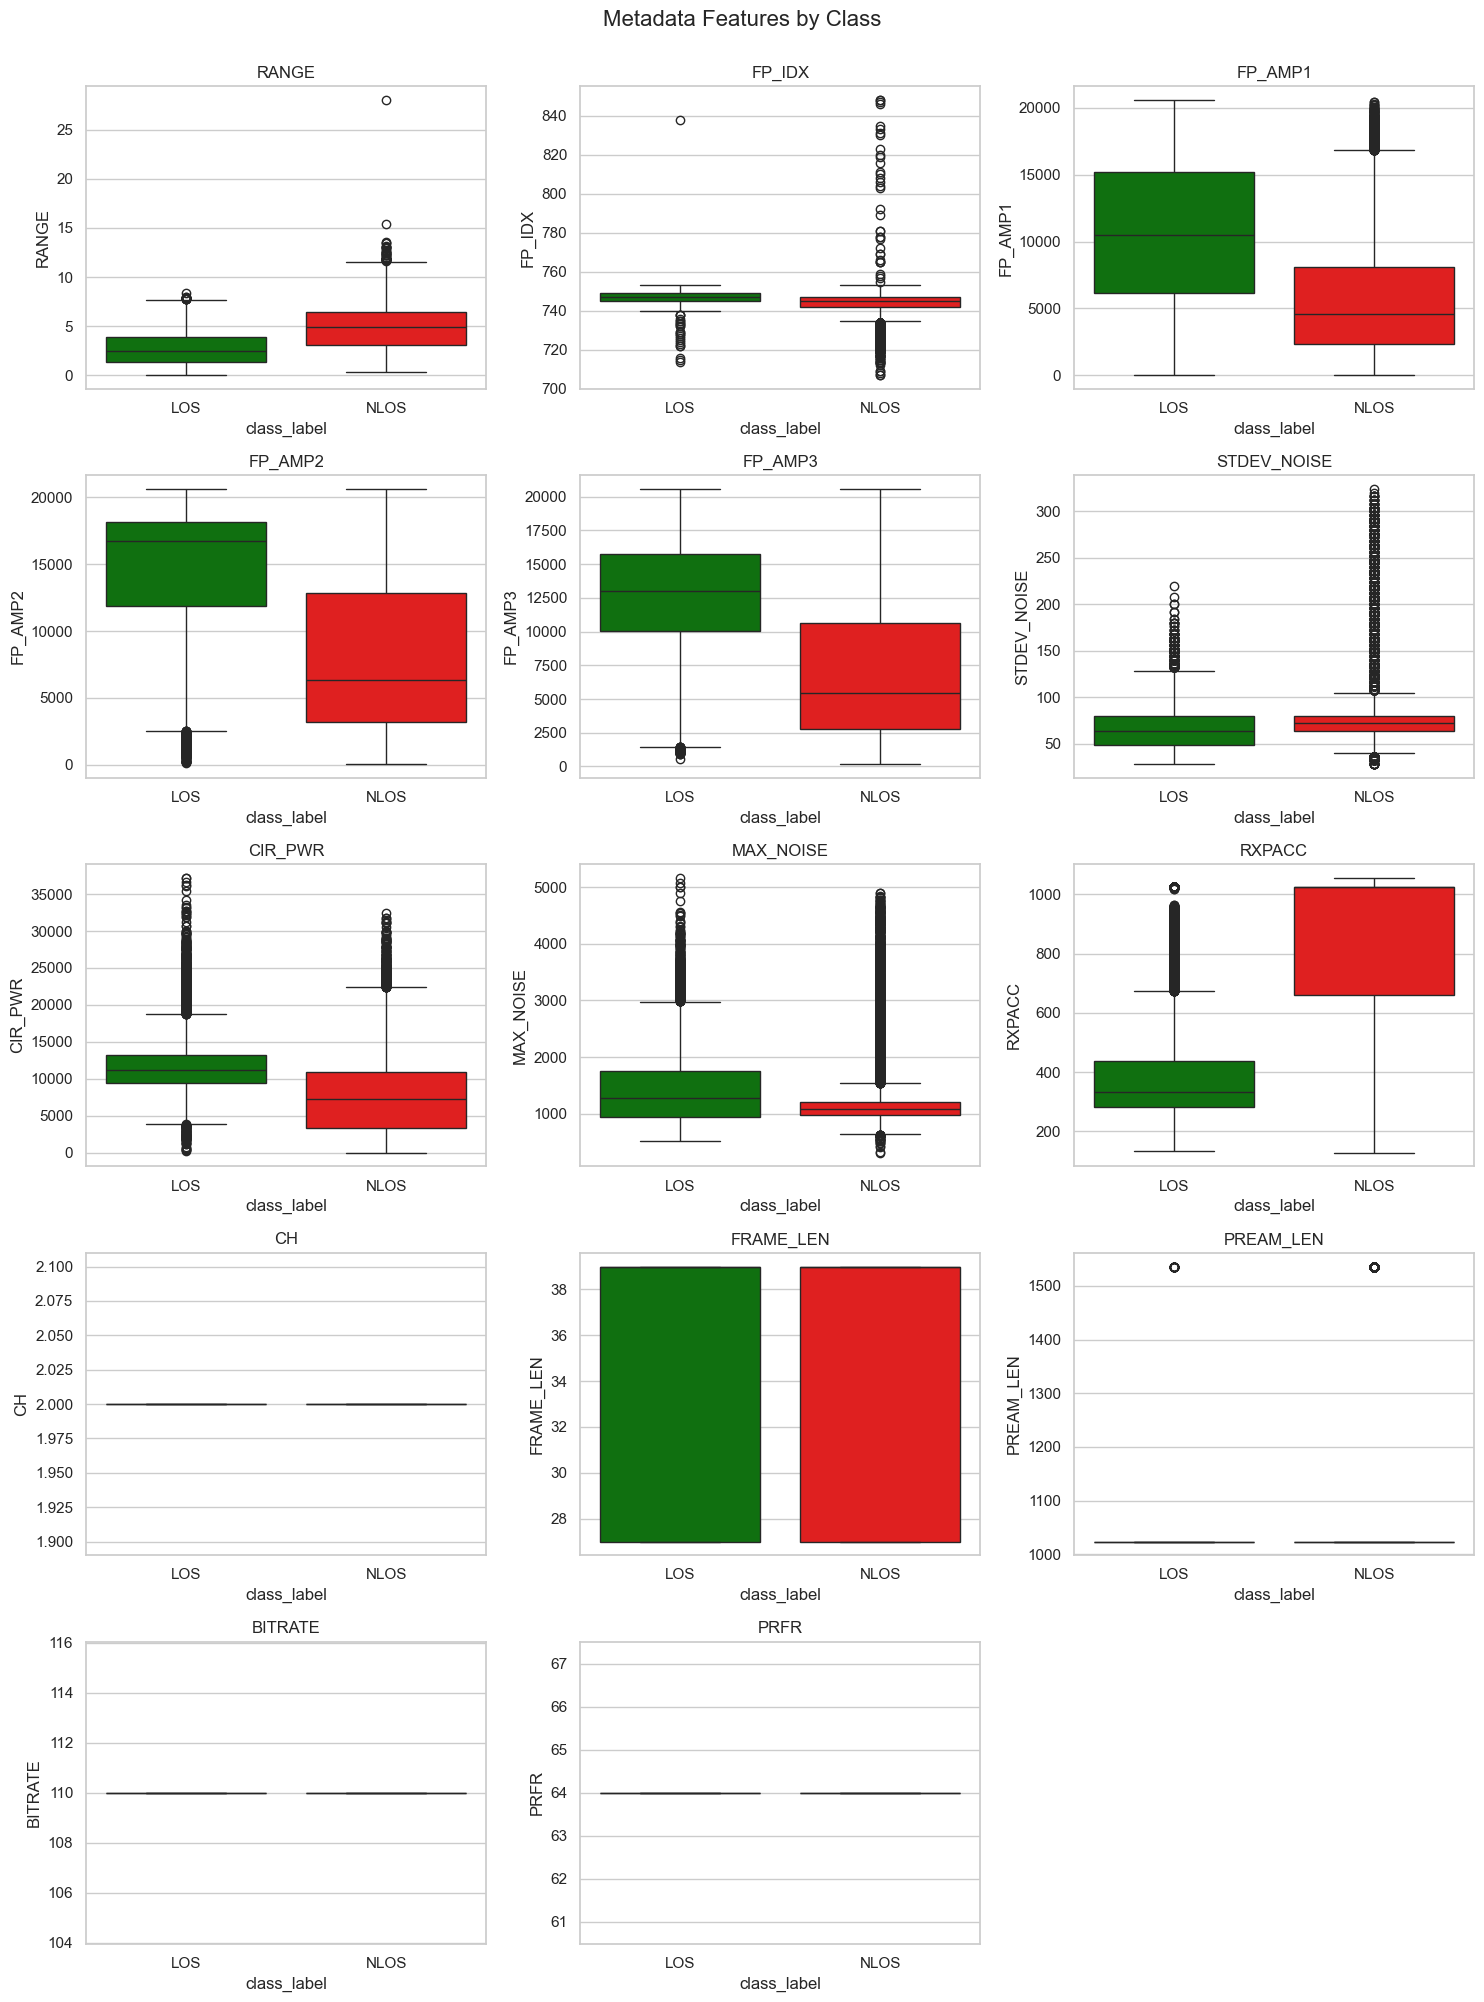

In [15]:
n_cols = 3
n_rows = int(np.ceil(len(metadata_cols)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(metadata_cols):

    sns.boxplot(
        data=df_raw,
        x="class_label",
        hue="class_label", 
        palette=["green", "red"],
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Metadata Features by Class", y=1, fontsize=16)
plt.tight_layout()
plt.show()

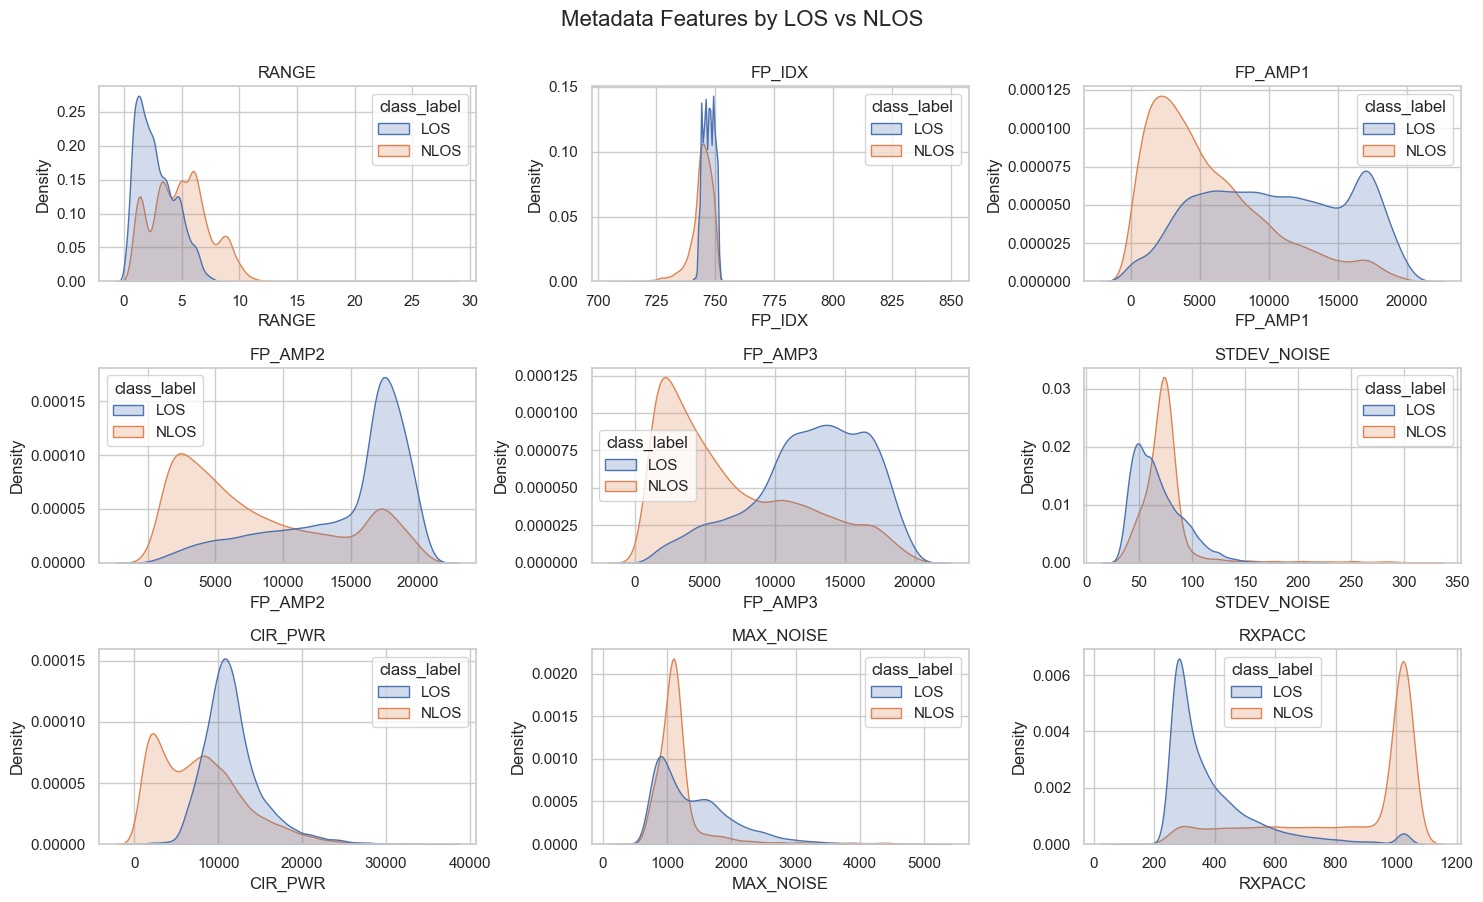

In [16]:
# Density Plot
key_features = ["RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3", "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC"]

n_rows = int(np.ceil(len(key_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))

axes = axes.flatten()

for i, col in enumerate(key_features):
    
    sns.kdeplot(
        data=df_raw,
        x=col,
        hue="class_label",
        fill=True,
        common_norm=False,
        ax=axes[i]
    )
    
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Metadata Features by LOS vs NLOS", y=1, fontsize=16)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis
A correlation heatmap was generated to examine relationships between metadata features and the target variable. This analysis helps identify features that may be strongly associated with LOS or NLOS conditions.

### Findings
- The correlation analysis indicates that **RXPACC** and **RANGE** demonstrate stronger association with the target variable compared to other metadata features.
- Certain signal amplitude features such as **FP_AMP2** and **FP_AMP3** show **negative correlation** with the target variable, indicating that their values tend to decrease when the likelihood of NLOS increases.
- Strong correlation between some metadata features (e.g., FP_AMP2 and FP_AMP3) suggests potential redundancy among these variables.
- Constant features such as CH, BITRATE, and PRFR produce undefined correlations due to zero variance and were excluded from further correlation analysis.

### Physical & Mathematical Explanation
- **Why does RXPACC correlate with NLOS?** RXPACC records the number of preamble symbols successfully accumulated by the receiver during synchronisation. In LOS, the direct-path signal arrives cleanly, enabling the DW1000 chip to lock onto a high-quality preamble and accumulate many symbols (high RXPACC). In NLOS, the distorted or attenuated preamble causes fewer valid accumulations (low RXPACC). The Pearson correlation $r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$ between RXPACC and the NLOS label is therefore meaningfully negative.

- **Why is FP_AMP negatively correlated with NLOS?** This follows directly from the attenuation physics described in Section 7 — stronger amplitudes ($\uparrow$ FP_AMP) correspond to LOS (label 0), so as NLOS probability increases (label → 1), amplitude decreases, yielding a negative correlation coefficient.

- **Note on correlation limitations:** Pearson correlation only measures *linear* relationships. A near-zero correlation does not mean a feature is useless — tree-based models and neural networks can capture non-linear interactions that correlation misses.

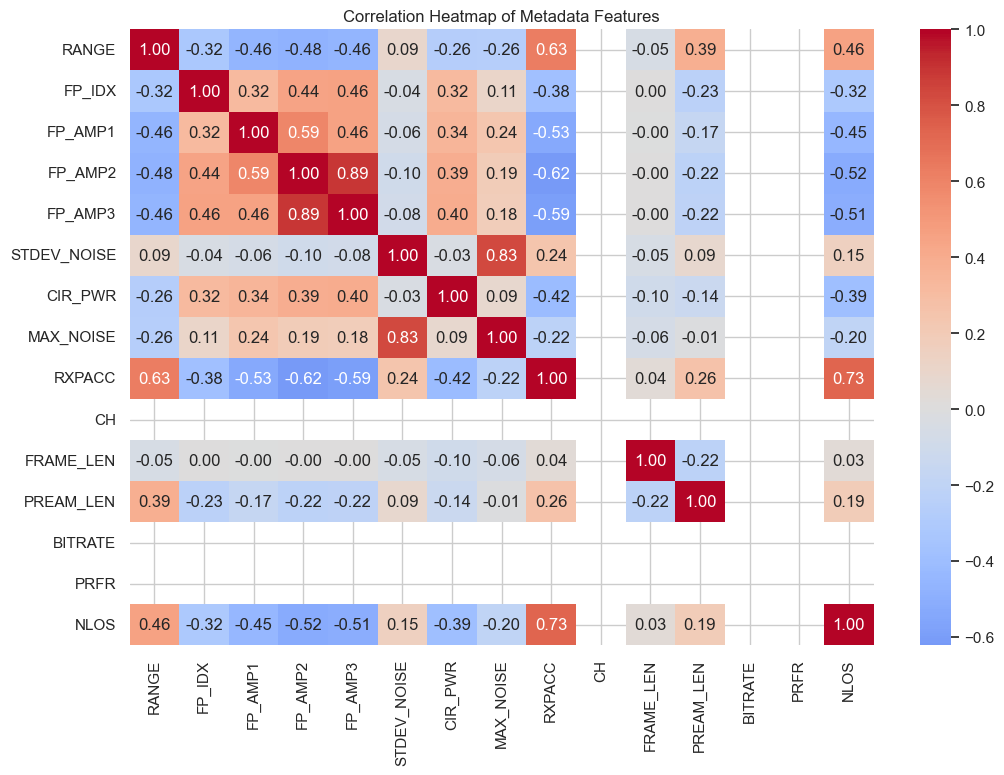

In [17]:
corr = df_raw[metadata_cols + [target_col]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Metadata Features")
plt.show()

In [18]:
target_corr = corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)

print("Correlation with NLOS target:")
target_corr.to_frame(name="corr_with_NLOS").T

Correlation with NLOS target:


,RXPACC,FP_AMP2,FP_AMP3,RANGE,FP_AMP1,CIR_PWR,FP_IDX,MAX_NOISE,PREAM_LEN,STDEV_NOISE,FRAME_LEN,CH,BITRATE,PRFR
corr_with_NLOS,0.73069,-0.524905,-0.514339,0.456845,-0.447279,-0.392303,-0.316978,-0.198198,0.189658,0.152291,0.034316,NaN,NaN,NaN


## 9. CIR Signal Exploration

The Channel Impulse Response (CIR) signals represent the waveform of the received UWB signal over time. Visualization of CIR samples allows observation of signal propagation patterns under LOS and NLOS conditions.

### Findings
- LOS signals typically exhibit stronger early peaks, corresponding to the direct signal path.
- NLOS signals tend to show more dispersed waveform patterns, reflecting signal reflections and multipath propagation.
- These patterns highlight the impact of environmental obstacles on signal propagation.

### Physical & Mathematical Explanation
The CIR describes the channel as a linear filter. The received signal is the convolution of the transmitted pulse $s(t)$ with the channel's impulse response:

$$h(t) = \sum_{i=1}^{N} \alpha_i \, \delta(t - \tau_i)$$

where $\alpha_i$ is the amplitude and $\tau_i$ is the propagation delay of the $i$-th multipath component.

- **LOS CIR:** The dominant component ($i=1$, the direct path) carries most of the energy. The CIR shows a sharp, isolated peak at the time-of-flight index. High kurtosis (concentrated energy) and low skewness characterise this profile.

- **NLOS CIR:** The direct path is attenuated or absent. Energy spreads across many reflected components arriving at varying delays, producing a broader, flatter waveform. This reduces kurtosis and increases the energy spread — the same statistics we use as engineered features in Section 12.

This mathematical structure is why the **1D CNN** can classify directly from the raw CIR: it learns to recognise the sharp-peak vs. spread-energy pattern without manual feature engineering, while the tabular models use the 8 statistical summaries of this same structure.

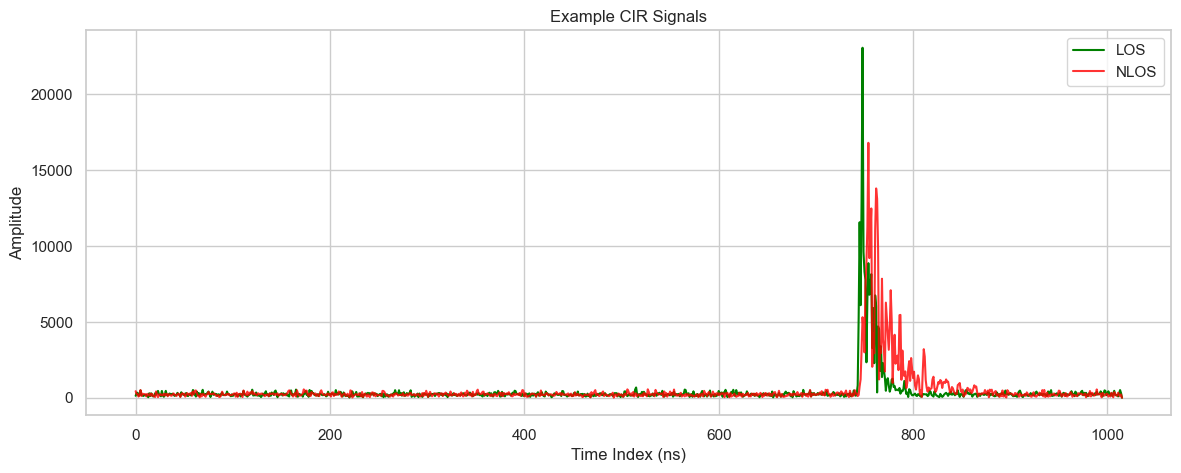

In [19]:
los_sample = df_raw[df_raw[target_col] == 0].iloc[0]
nlos_sample = df_raw[df_raw[target_col] == 1].iloc[0]

plt.figure(figsize=(14,5))
plt.plot(range(len(cir_cols)), los_sample[cir_cols].values, label="LOS", color="green")
plt.plot(range(len(cir_cols)), nlos_sample[cir_cols].values, label="NLOS", color="red", alpha=0.8)
plt.title("Example CIR Signals")
plt.xlabel("Time Index (ns)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

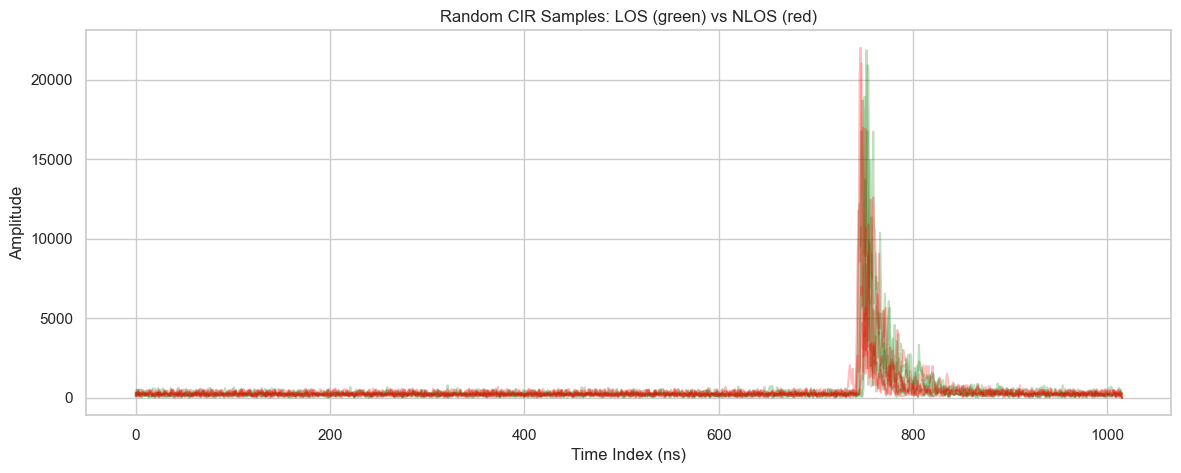

In [20]:
plt.figure(figsize=(14, 5))

for _, row in df_raw[df_raw[target_col] == 0].sample(5, random_state=42).iterrows():
    plt.plot(row[cir_cols].values, color="green", alpha=0.25)

for _, row in df_raw[df_raw[target_col] == 1].sample(5, random_state=42).iterrows():
    plt.plot(row[cir_cols].values, color="red", alpha=0.25)

plt.title("Random CIR Samples: LOS (green) vs NLOS (red)")
plt.xlabel("Time Index (ns)")
plt.ylabel("Amplitude")
plt.show()

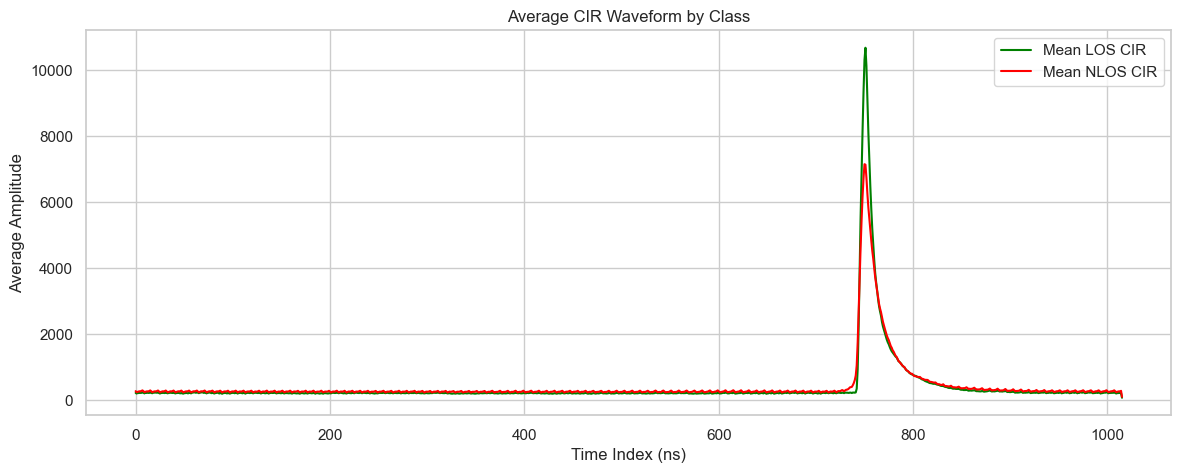

In [21]:
los_mean = df_raw[df_raw[target_col] == 0][cir_cols].mean(axis=0)
nlos_mean = df_raw[df_raw[target_col] == 1][cir_cols].mean(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(los_mean.values, label="Mean LOS CIR", color="green")
plt.plot(nlos_mean.values, label="Mean NLOS CIR", color="red")
plt.title("Average CIR Waveform by Class")
plt.xlabel("Time Index (ns)")
plt.ylabel("Average Amplitude")
plt.legend()
plt.show()

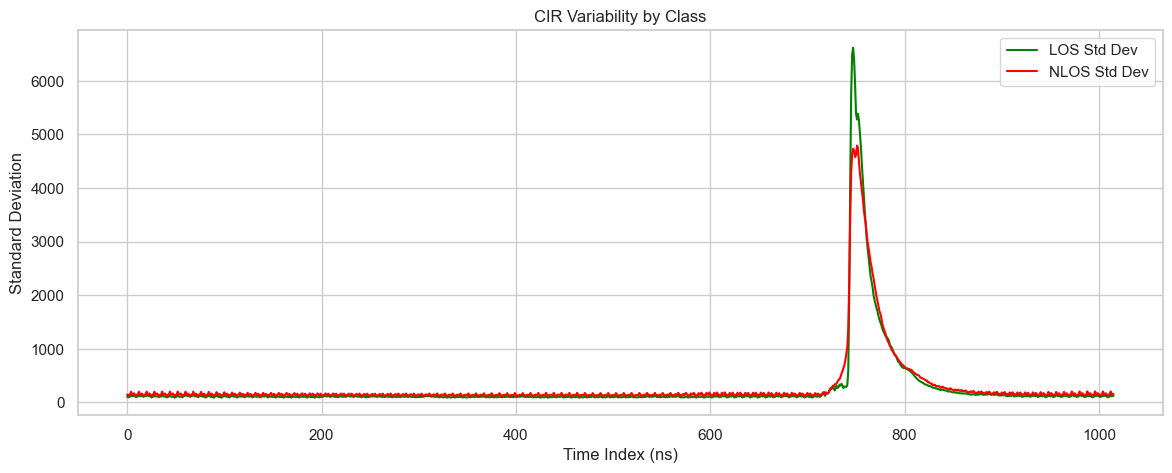

In [22]:
los_std = df_raw[df_raw[target_col] == 0][cir_cols].std(axis=0)
nlos_std = df_raw[df_raw[target_col] == 1][cir_cols].std(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(los_std.values, label="LOS Std Dev", color="green")
plt.plot(nlos_std.values, label="NLOS Std Dev", color="red")
plt.title("CIR Variability by Class")
plt.xlabel("Time Index (ns)")
plt.ylabel("Standard Deviation")
plt.legend()
plt.show()

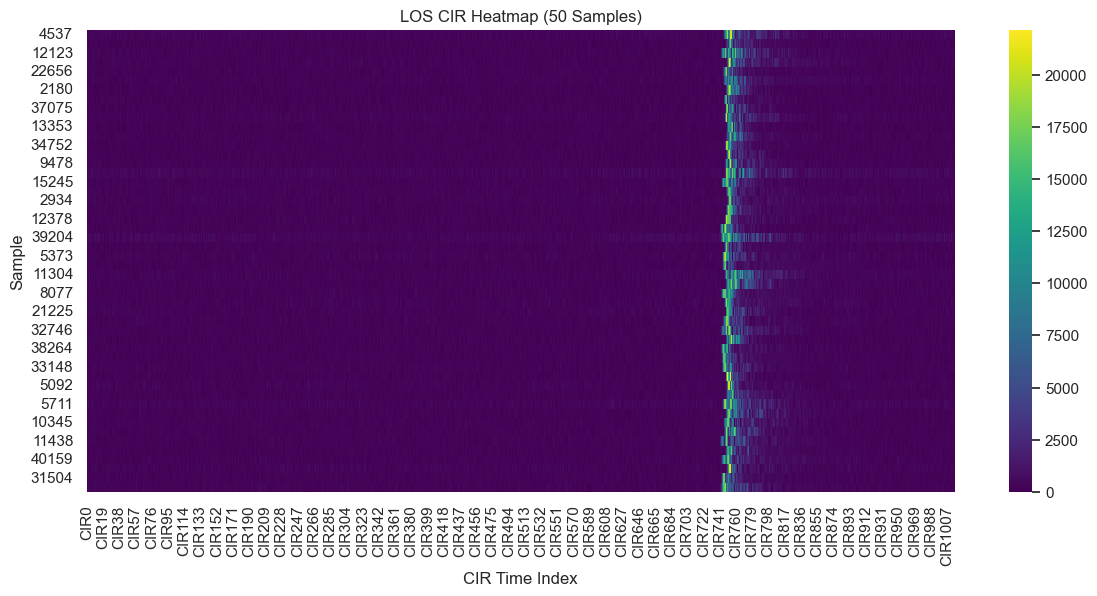

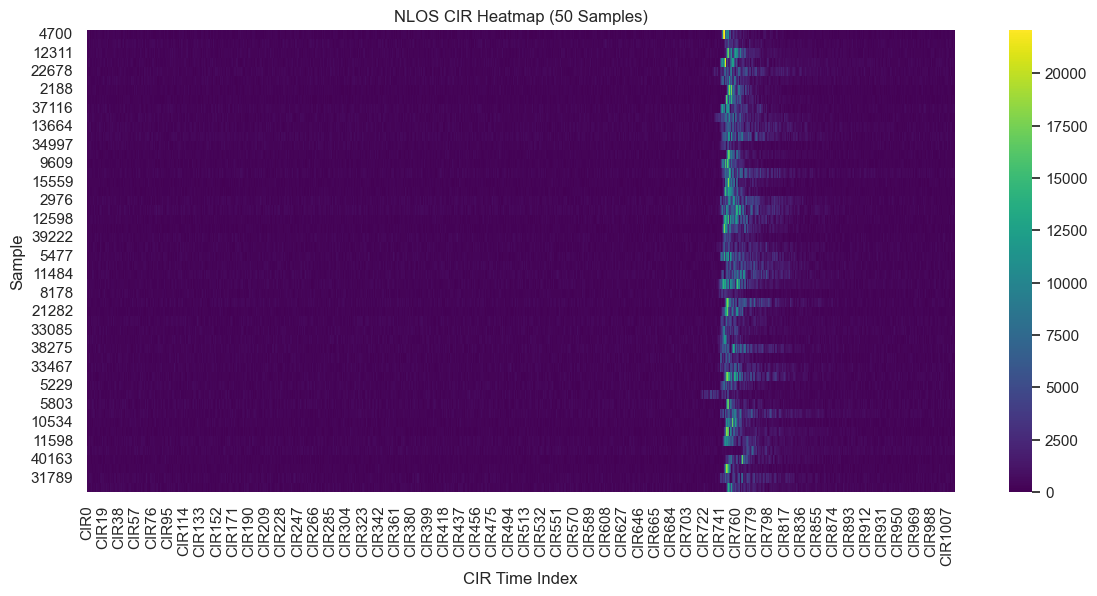

In [23]:
los_heatmap = df_raw[df_raw[target_col] == 0][cir_cols].sample(50, random_state=42)
nlos_heatmap = df_raw[df_raw[target_col] == 1][cir_cols].sample(50, random_state=42)

plt.figure(figsize=(14, 6))
sns.heatmap(los_heatmap, cmap="viridis", cbar=True)
plt.title("LOS CIR Heatmap (50 Samples)")
plt.xlabel("CIR Time Index")
plt.ylabel("Sample")
plt.show()

plt.figure(figsize=(14, 6))
sns.heatmap(nlos_heatmap, cmap="viridis", cbar=True)
plt.title("NLOS CIR Heatmap (50 Samples)")
plt.xlabel("CIR Time Index")
plt.ylabel("Sample")
plt.show()

## 10. Dimensionality Exploration with PCA

Principal Component Analysis (PCA) finds orthogonal directions of maximum variance in the data. Given a centred data matrix $X \in \mathbb{R}^{n \times p}$, PCA computes the eigendecomposition of the covariance matrix $\Sigma = \frac{1}{n-1}X^\top X$. Each eigenvector is a principal component (PC); its eigenvalue is the proportion of total variance that component explains.

We apply PCA in two separate contexts:

1. **Metadata features (11 features):** A quick sanity check — can the 11 signal statistics alone separate LOS from NLOS in 2D?
2. **CIR columns (1,016 features):** The dimensionally rich subspace. This is where dimensionality reduction actually matters — 1,016 raw samples per measurement is expensive for tabular models. The scree plot here directly justifies extracting 8 compact statistical features instead.

### Findings — Metadata PCA
- Only 53.6% of variance is explained by 2 components, confirming that the 11 metadata features alone do not cleanly separate the classes. Additional features (CIR statistics) are required.

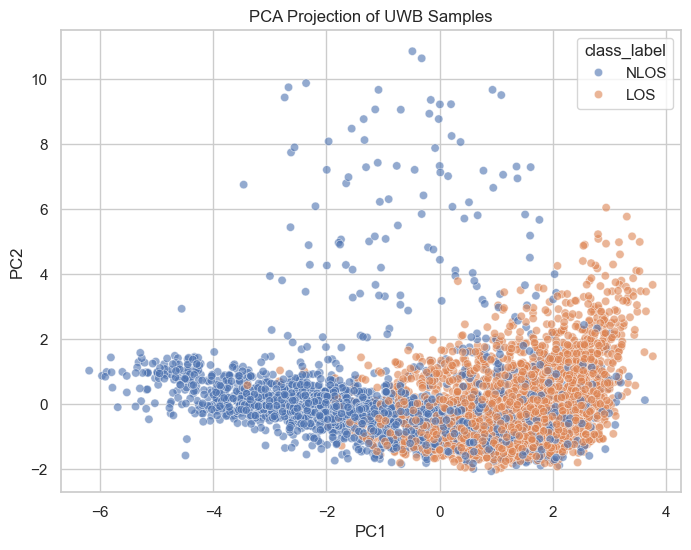

Explained variance ratio: [0.36850871 0.16759758]
Total explained variance: 0.5361062935351795


In [24]:
sample_df = df_raw.sample(5000, random_state=42).copy()

# metadata only
df_meta = sample_df[metadata_cols]

# remove constant columns such as CH, BITRATE, PRFR
df_meta = df_meta.loc[:, df_meta.nunique() > 1]

X = df_meta

y = sample_df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "class_label": y.map({0: "LOS", 1: "NLOS"})
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class_label", alpha=0.6)
plt.title("PCA Projection of UWB Samples")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

### PCA on CIR Columns (1,016 features)

The 1,016 CIR amplitude samples per measurement form a very high-dimensional feature space. The questions we want to answer:
- How many principal components are needed to capture 90% / 95% of the CIR variance?
- Does the compressed representation still separate LOS from NLOS?

The answers justify the preprocessing choice: if X components capture 95% of the CIR variance (far fewer than 1,016), then the 8 statistical features we extract are a compact and physically interpretable proxy for the dominant sources of variation in the CIR signal.

Fitting PCA on CIR columns (5,000 samples × 1,016 features)...


Components to capture 90% variance: 201
Components to capture 95% variance: 201
Variance explained by first 2 components: 41.8%
Total variance explained by 200 components: 68.4%


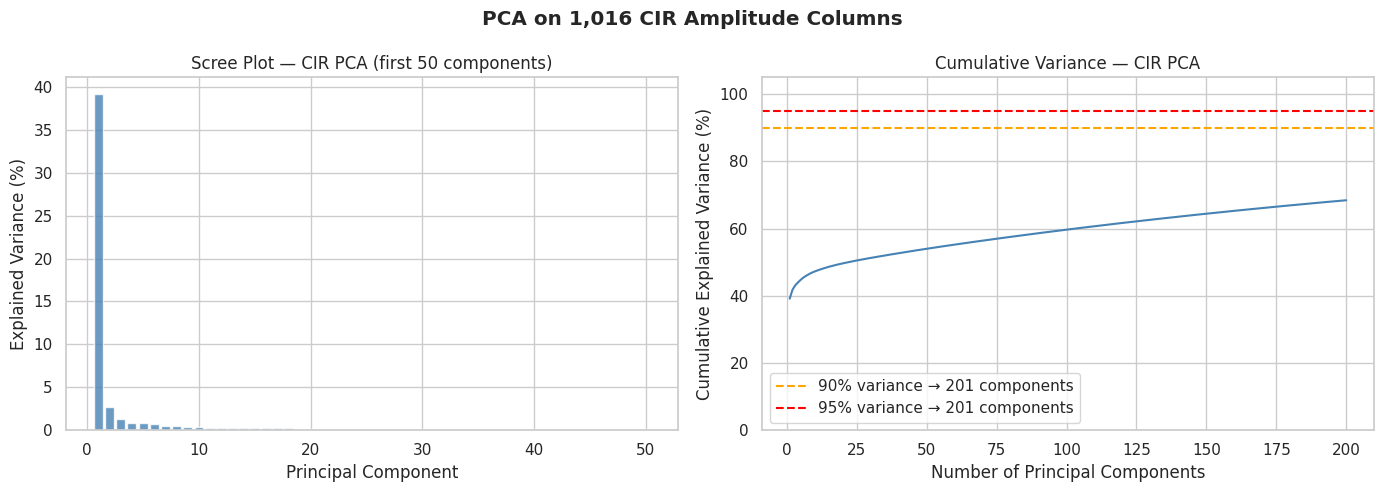

In [13]:
# ── PCA on CIR columns ────────────────────────────────────────────────────────
# Sample for speed — 5,000 rows is enough for a reliable variance estimate
cir_sample_df = df_raw.sample(5000, random_state=42).copy()
cir_matrix_pca = cir_sample_df[cir_cols].values.astype(np.float32)

# Normalise by RXPACC (same as Section 12 preprocessing)
rxpacc_pca = cir_sample_df['RXPACC'].values.reshape(-1, 1).astype(np.float32)
cir_matrix_pca = cir_matrix_pca / (rxpacc_pca + 1e-8)

# Standardise before PCA
scaler_cir = StandardScaler()
cir_scaled = scaler_cir.fit_transform(cir_matrix_pca)

# Fit PCA with enough components to exceed 95% variance
# Use n_components=0.99 to let sklearn determine the cutoff, but plot the first 100
print("Fitting PCA on CIR columns (5,000 samples × 1,016 features)...")
pca_cir_full = PCA(n_components=200, random_state=42, svd_solver='randomized')
pca_cir_full.fit(cir_scaled)

evr = pca_cir_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

# Find elbow points
idx_90 = np.searchsorted(cumvar, 0.90)
idx_95 = np.searchsorted(cumvar, 0.95)
n_90 = int(idx_90) + 1
n_95 = int(idx_95) + 1
print(f"Components to capture 90% variance: {n_90}")
print(f"Components to capture 95% variance: {n_95}")
print(f"Variance explained by first 2 components: {cumvar[1]:.1%}")
print(f"Total variance explained by 200 components: {cumvar[-1]:.1%}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (bar) — first 50 for readability
axes[0].bar(range(1, 51), evr[:50] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — CIR PCA (first 50 components)")

# Cumulative variance curve
axes[1].plot(range(1, 201), cumvar * 100, linewidth=1.5, color='steelblue')
axes[1].axhline(90, color='orange', linestyle='--', label=f'90% variance → {n_90} components')
axes[1].axhline(95, color='red', linestyle='--', label=f'95% variance → {n_95} components')
if idx_90 < 200:
    axes[1].axvline(n_90, color='orange', linestyle=':', alpha=0.7)
if idx_95 < 200:
    axes[1].axvline(n_95, color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Variance — CIR PCA")
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle("PCA on 1,016 CIR Amplitude Columns", fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/05_cir_pca_scree.png', dpi=120, bbox_inches='tight')
plt.show()

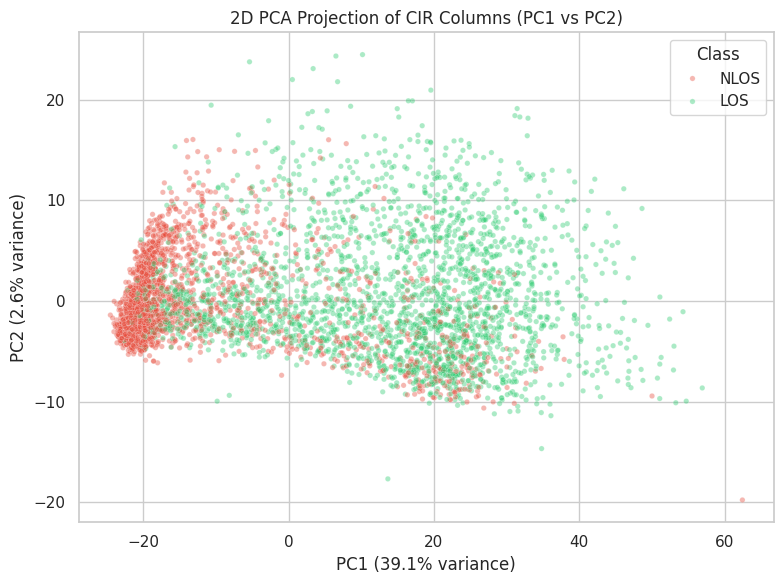

PC1 + PC2 combined variance: 41.8%


In [14]:
# ── 2D CIR PCA scatter — LOS vs NLOS separation ──────────────────────────────
pca_cir_2d = PCA(n_components=2, random_state=42)
cir_2d = pca_cir_2d.fit_transform(cir_scaled)

pca_cir_df = pd.DataFrame({
    "PC1": cir_2d[:, 0],
    "PC2": cir_2d[:, 1],
    "Class": cir_sample_df[target_col].map({0: "LOS", 1: "NLOS"}).values,
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_cir_df, x="PC1", y="PC2", hue="Class",
                palette={"LOS": "#2ecc71", "NLOS": "#e74c3c"}, alpha=0.4, s=15)
plt.title("2D PCA Projection of CIR Columns (PC1 vs PC2)")
plt.xlabel(f"PC1 ({pca_cir_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_cir_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.savefig('results/figures/06_cir_pca_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"PC1 + PC2 combined variance: {pca_cir_2d.explained_variance_ratio_.sum():.1%}")

### Findings — CIR PCA

The scree plot and cumulative variance curve reveal important properties of the CIR signal:

- **Strong first component (~39% variance):** PC1 dominates — this component likely captures the overall signal energy level, which differs systematically between LOS and NLOS due to path loss. The dramatic drop after PC2 confirms a single dominant mode.

- **Long tail — high intrinsic dimensionality:** 200 components explain only ~68% of variance. Unlike image data, the CIR is mostly noise with localised signal peaks whose positions vary between samples (FP_IDX ranges from 707–848 across the dataset). This position jitter means adjacent CIR samples are largely uncorrelated, spreading variance across many dimensions.

- **Implication for feature engineering:** Because PCA cannot compress the CIR into a small number of global components, we need *domain-aware* feature extraction rather than unsupervised compression. The 8 statistical features (max, energy, kurtosis, etc.) capture physically interpretable properties of the waveform that generalise across the position-variable CIR structure. The 1D CNN avoids this problem entirely by learning translation-invariant patterns directly.

- **2D projection:** The next cell shows partial class separation even in 2D (PC1+PC2 = ~42% variance), confirming that CIR shape carries discriminative signal even in the compressed representation.

## 11. Key EDA Findings Summary

- The merged dataset contains all **7 dataset parts** and is **balanced** between **LOS and NLOS samples**.
- Data quality checks confirm that the dataset contains **no missing values** and **no duplicate records**.
- Metadata features describing signal strength and noise exhibit different distributions across LOS and NLOS conditions. Physical multipath theory explains why: NLOS signals show higher noise (interference from multiple reflected paths) and lower first-path amplitudes (signal attenuation through obstacles).
- Correlation analysis highlights that **RXPACC** has the strongest association with the target — lower preamble accumulation indicates a degraded NLOS channel.
- CIR waveform visualization confirms the expected LOS (sharp peak) vs. NLOS (broad, spread) pattern, consistent with the channel impulse response model $h(t) = \sum_i \alpha_i \delta(t - \tau_i)$.
- **PCA on 11 metadata features** captures only 53.6% of variance in 2 components — metadata alone is insufficient for clean separation.
- **PCA on 1,016 CIR columns** shows that PC1 (~39% variance) separates LOS from NLOS along the energy axis, with visible class clustering in 2D. However, the high intrinsic dimensionality of the CIR (200 components explain only ~68% of variance) motivates domain-aware feature extraction rather than unsupervised compression.

In [25]:
eda_overview = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "missing": df_raw.isna().sum(),
    "n_unique": df_raw.nunique(),
    "sample_value": df_raw.iloc[0]
})

eda_overview.head(30)

,dtype,missing,n_unique,sample_value
NLOS,float64,0,2,0.0
RANGE,float64,0,1160,3.9
FP_IDX,float64,0,76,745.0
FP_AMP1,float64,0,16693,18712.0
FP_AMP2,float64,0,16533,10250.0
FP_AMP3,float64,0,16614,11576.0
STDEV_NOISE,float64,0,75,64.0
CIR_PWR,float64,0,16591,11855.0
MAX_NOISE,float64,0,3056,967.0
RXPACC,float64,0,725,611.0


## 12. Data Preprocessing

### Data Cleaning

There are no missing values — the DWM1000 hardware always populates every output field. No duplicate rows were found. Amplitude outliers from strong LOS signals are kept since they reflect real measurements, not sensor faults. The dataset is already balanced (21,000 LOS, 21,000 NLOS) so no resampling was needed.

### Removing Zero-Variance Features

Columns `CH`, `BITRATE`, and `PRFR` are constant across all 42,000 samples — they carry no information and are dropped. `dataset_part` and `class_label` are also removed since they are metadata, not signal measurements.

### CIR Dimensionality Reduction

The raw CIR has 1,016 amplitude samples per measurement. Using all 1,016 directly would be computationally expensive and create a very high-dimensional feature space. We extract 8 statistical descriptors that capture the key differences between LOS and NLOS channel profiles:

| Feature | Physical Meaning |
|---|---|
| `cir_mean` | Average amplitude |
| `cir_std` | Signal spread |
| `cir_max` | Peak amplitude |
| `cir_peak_idx` | Index of dominant path |
| `cir_energy` | Total signal energy |
| `cir_kurtosis` | Peak sharpness — LOS has a sharp concentrated peak (high kurtosis); NLOS spreads energy across multiple reflections (lower kurtosis) |
| `cir_skewness` | Waveform asymmetry |
| `cir_rms` | Root mean square amplitude |

In [15]:
df_raw = df_raw.reset_index(drop=True).copy()
df_raw['row_id'] = df_raw.index

# ── Drop zero-variance & metadata columns ─────────────────────────────────────
TARGET_CLASS = 'NLOS'
TARGET_REG   = 'RANGE'
DROP_COLS    = ['CH', 'BITRATE', 'PRFR', 'dataset_part', 'class_label']

existing_drop = [c for c in DROP_COLS if c in df_raw.columns]
df_preprocess = df_raw.drop(columns=existing_drop)

print(f"Dropped {len(existing_drop)} columns: {existing_drop}")
print(f"Dataframe shape before: {df_raw.shape} → after: {df_preprocess.shape}")

METADATA_FEATURES = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN'
]

cir_cols_clean = sorted(
    [c for c in df_preprocess.columns if c.startswith('CIR') and c[3:].isdigit()],
    key=lambda x: int(x[3:])
)

print(f"Metadata features : {len(METADATA_FEATURES)}")
print(f"CIR columns       : {len(cir_cols_clean)}")

Dropped 4 columns: ['CH', 'BITRATE', 'PRFR', 'dataset_part']
Dataframe shape before: (42000, 1033) → after: (42000, 1029)
Metadata features : 11
CIR columns       : 1016


In [16]:
# ── CIR statistical feature extraction ───────────────────────────────────────
print("Extracting CIR statistical features (this may take ~30 seconds)...")

cir_matrix = df_preprocess[cir_cols_clean].values.astype(np.float32)

# Normalise by RXPACC (number of acquired RX preamble samples) — physically
# correct for DW1000 CIR data: dividing by RXPACC makes amplitude values
# comparable across measurements with different preamble accumulation counts.
rxpacc_vals = df_preprocess['RXPACC'].values.reshape(-1, 1).astype(np.float32)
cir_matrix  = cir_matrix / (rxpacc_vals + 1e-8)

cir_stats = pd.DataFrame({
    'cir_mean'      : np.mean(cir_matrix, axis=1),
    'cir_std'       : np.std(cir_matrix, axis=1),
    'cir_max'       : np.max(cir_matrix, axis=1),
    'cir_peak_idx'  : np.argmax(cir_matrix, axis=1).astype(float),
    'cir_energy'    : np.sum(cir_matrix ** 2, axis=1),
    'cir_kurtosis'  : kurtosis(cir_matrix, axis=1),
    'cir_skewness'  : skew(cir_matrix, axis=1),
    'cir_rms'       : np.sqrt(np.mean(cir_matrix ** 2, axis=1)),
})

cir_stats['row_id'] = df_preprocess['row_id'].values

print(f"CIR statistical features shape: {cir_stats.shape}")
cir_stats.describe().round(2)

Extracting CIR statistical features (this may take ~30 seconds)...


CIR statistical features shape: (42000, 9)


,cir_mean,cir_std,cir_max,cir_peak_idx,cir_energy,cir_kurtosis,cir_skewness,cir_rms,row_id
count,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00
mean,0.85,2.38,36.30,750.88,8589.34,111.58,9.52,2.54,20999.50
std,0.39,1.38,22.59,5.15,7615.95,48.40,2.22,1.42,12124.50
min,0.29,0.26,2.61,716.00,164.05,-1.15,-0.49,0.40,0.00
25%,0.46,0.99,13.68,748.00,1233.78,73.32,7.85,1.10,10499.75
50%,0.81,2.37,35.16,750.00,6361.24,106.69,9.50,2.50,20999.50
75%,1.20,3.68,57.10,753.00,15291.05,145.02,11.19,3.88,31499.25
max,1.90,5.08,86.79,950.00,28176.91,326.59,16.74,5.27,41999.00


### CIR Statistical Feature Separation by Class

The 8 engineered CIR features bridge EDA and modelling. Here we visualise how well each feature separates LOS from NLOS — this directly validates the feature engineering choice before training any model.

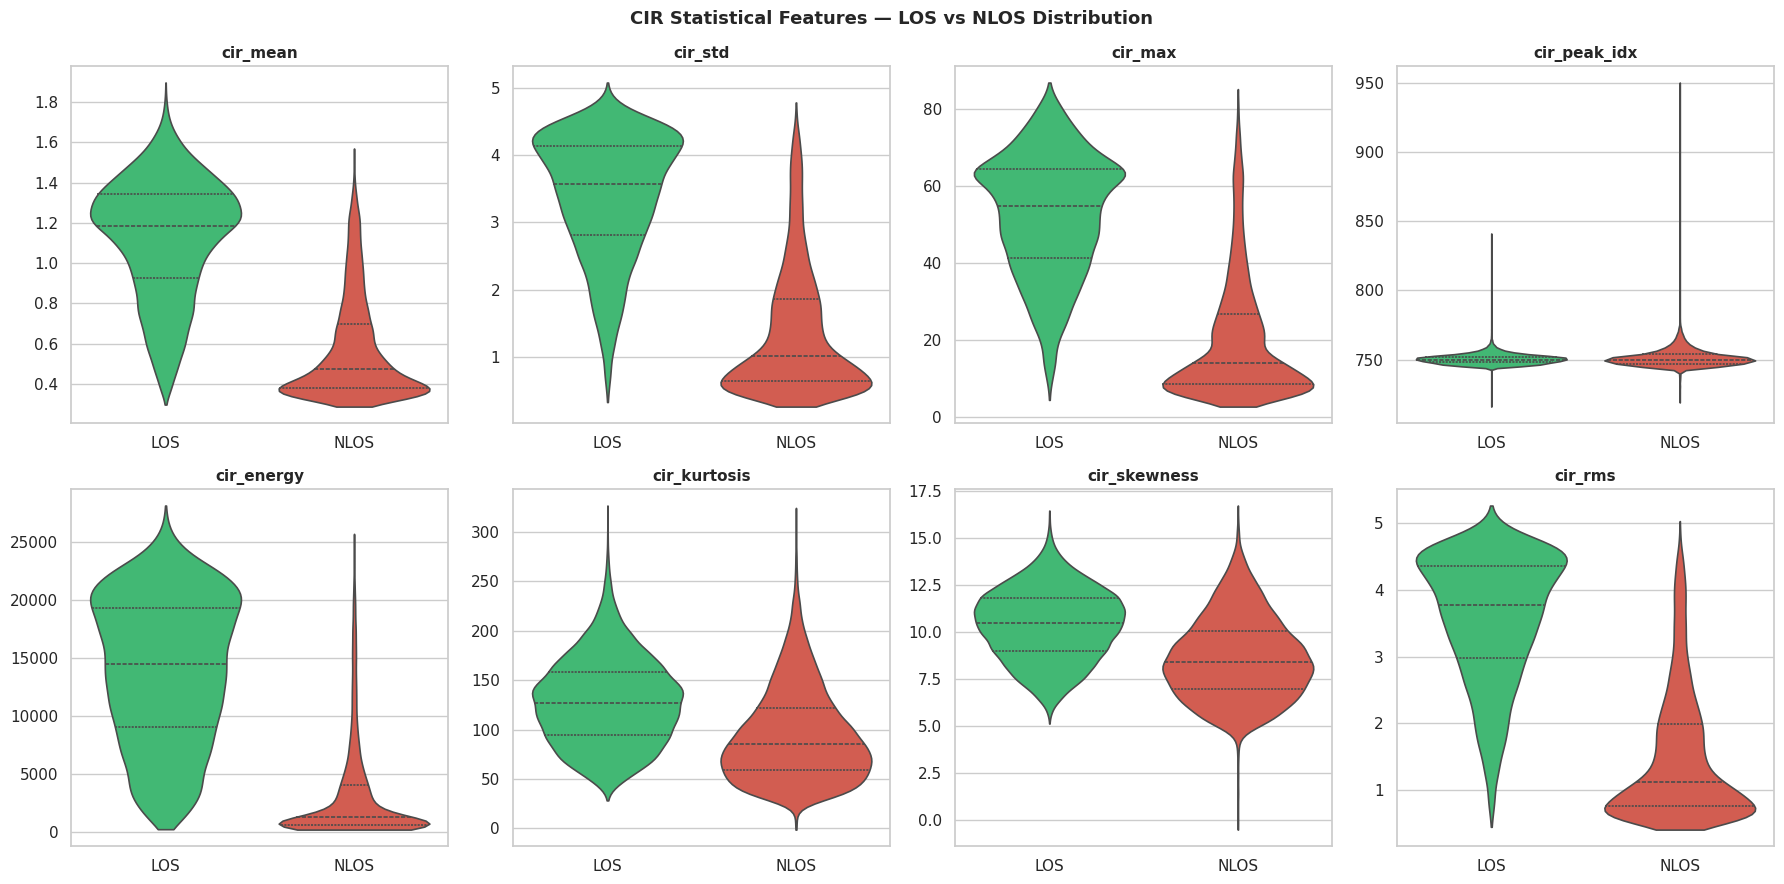

Feature separation summary (median difference ÷ pooled std):
  cir_mean            separation index = 2.580
  cir_std             separation index = 2.750
  cir_max             separation index = 2.580
  cir_peak_idx        separation index = 0.000
  cir_energy          separation index = 2.493
  cir_kurtosis        separation index = 0.916
  cir_skewness        separation index = 1.019
  cir_rms             separation index = 2.763


In [17]:
# ── Violin plots of 8 CIR statistical features by LOS/NLOS ──────────────────
cir_feat_names = ['cir_mean', 'cir_std', 'cir_max', 'cir_peak_idx',
                  'cir_energy', 'cir_kurtosis', 'cir_skewness', 'cir_rms']

# Combine CIR stats with target label for plotting
plot_df = cir_stats[cir_feat_names].copy()
plot_df['Class'] = df_preprocess['NLOS'].map({0: 'LOS', 1: 'NLOS'}).values

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

palette = {'LOS': '#2ecc71', 'NLOS': '#e74c3c'}

for i, feat in enumerate(cir_feat_names):
    sns.violinplot(
        data=plot_df, x='Class', y=feat, ax=axes[i],
        palette=palette, inner='quartile', cut=0, linewidth=1.2
    )
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle("CIR Statistical Features — LOS vs NLOS Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/07_cir_features_violin.png', dpi=120, bbox_inches='tight')
plt.show()

# Summarise which features show clearest separation
print("Feature separation summary (median difference ÷ pooled std):")
for feat in cir_feat_names:
    los_vals  = plot_df.loc[plot_df['Class'] == 'LOS',  feat]
    nlos_vals = plot_df.loc[plot_df['Class'] == 'NLOS', feat]
    pooled_std = ((los_vals.std() + nlos_vals.std()) / 2)
    sep = abs(los_vals.median() - nlos_vals.median()) / (pooled_std + 1e-9)
    print(f"  {feat:<18}  separation index = {sep:.3f}")

### Findings — CIR Feature Separation

The separation index (median difference ÷ pooled std, similar to Cohen's d) shows which features best discriminate LOS from NLOS:

| Feature | Separation | Interpretation |
|---|---|---|
| `cir_rms` | **2.76** | Strong — RMS amplitude is directly tied to total received energy; LOS signals carry more energy via the direct path |
| `cir_std` | **2.75** | Strong — amplitude spread is higher in LOS where the dominant peak creates large variance relative to the noise floor |
| `cir_mean`, `cir_max` | **~2.58** | Strong — same energy argument; LOS amplitude is systematically higher |
| `cir_energy` | **2.49** | Strong — sum of squared amplitudes; physically equivalent to total signal power |
| `cir_skewness` | **1.02** | Moderate — LOS waveforms are more right-skewed (sharp peak at the direct path delay) |
| `cir_kurtosis` | **0.92** | Moderate — LOS CIR has a sharper, more peaked distribution, but high variance limits separation |
| `cir_peak_idx` | **0.00** | No separation — the peak index (related to distance, not LOS/NLOS) varies with range, not channel condition |

**Key takeaway:** The energy-based features (RMS, std, max, mean, energy) show the clearest separation because the core difference between LOS and NLOS is the energy level of the received signal. `cir_peak_idx` is correctly excluded from classification (it encodes range, not channel condition) but remains useful for regression.

## 13. Export preprocessed data for modelling

In [18]:
# Ensures that row ID matches before concatinating
print((df_preprocess['row_id'].values == cir_stats['row_id'].values).all())

True


In [19]:
# Append CIR statistical features
df_export = pd.concat(
    [
        df_preprocess.reset_index(drop=True),
        cir_stats.drop(columns=['row_id']).reset_index(drop=True)
    ],
    axis=1
)

# Drop temporary row_id before export
if 'row_id' in df_export.columns:
    df_export = df_export.drop(columns=['row_id'])

# Export
data_dir = Path("data")

if data_dir.exists():
    print(f"Folder already exists: {data_dir.resolve()}")
else:
    data_dir.mkdir(parents=True, exist_ok=True)
    print(f"Created folder: {data_dir.resolve()}")

output_file = data_dir / "uwb_preprocessed_for_ml.csv"
df_export.to_csv(output_file, index=False)

print(f"Exported to: {output_file.resolve()}")

Created folder: /home/william/school_projects/CSC3105_Group14/data


Exported to: /home/william/school_projects/CSC3105_Group14/data/uwb_preprocessed_for_ml.csv
